In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Dataset
data=pd.read_csv("Crop_Recommendation.csv")
data

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


In [3]:
# Data cleaning
data.isnull().sum()

,0
Nitrogen,0
Phosphorus,0
Potassium,0
Temperature,0
Humidity,0
pH_Value,0
Rainfall,0
Crop,0


In [4]:
data.columns

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop'],
      dtype='object')

In [5]:
data['Crop'].unique()

array(['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas',
       'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate',
       'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple',
       'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee'],
      dtype=object)

In [6]:
x=data[["Temperature","Humidity","Rainfall"]]
y=data[["Crop"]]

In [7]:
# Train data
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
k=KNeighborsClassifier(n_neighbors=3)

k.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [9]:
# Get input from the user
temp=int(input("Enter temperature:"))
humidity=int(input("Enter Humidity:"))
rainfall=int(input("Enter Rainfall:"))

new_prediction=[[temp,humidity,rainfall]]
Y_prediction=k.predict(new_prediction)

print("\n Predicted crop :",Y_prediction)

Enter temperature:22
Enter Humidity:70
Enter Rainfall:200

 Predicted crop : ['Jute']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [10]:
# validation
from sklearn.metrics import confusion_matrix,r2_score


In [11]:
Y_test

,Crop
1451,Muskmelon
1334,Watermelon
1761,Papaya
1735,Papaya
1576,Apple
...,...
59,Rice
71,Rice
1908,Cotton
1958,Cotton


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
le=LabelEncoder()
data['Crop']=le.fit_transform(data['Crop'])
data['Crop']

,Crop
0,20
1,20
2,20
3,20
4,20
...,...
2195,5
2196,5
2197,5
2198,5


In [14]:
data

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,5
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,5
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,5
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,5


In [15]:
Y_prediction=k.predict(X_test)
Y_prediction

array(['Muskmelon', 'MungBean', 'Papaya', 'Orange', 'Orange', 'Mango',
       'Pomegranate', 'MothBeans', 'MungBean', 'Lentil', 'Blackgram',
       'Coconut', 'Pomegranate', 'Jute', 'Coconut', 'Pomegranate',
       'Orange', 'Maize', 'Papaya', 'Muskmelon', 'Coffee', 'Papaya',
       'Orange', 'Coconut', 'ChickPea', 'Jute', 'Watermelon', 'Apple',
       'Coffee', 'Rice', 'Orange', 'MothBeans', 'Jute', 'Lentil', 'Jute',
       'Blackgram', 'Jute', 'ChickPea', 'ChickPea', 'KidneyBeans',
       'Papaya', 'Mango', 'Blackgram', 'Maize', 'MungBean', 'Maize',
       'Coffee', 'Coconut', 'Muskmelon', 'Blackgram', 'Blackgram',
       'Coffee', 'Grapes', 'MungBean', 'Coffee', 'KidneyBeans', 'Cotton',
       'Apple', 'Banana', 'Blackgram', 'Watermelon', 'Coconut', 'Lentil',
       'Orange', 'Papaya', 'Maize', 'Orange', 'Rice', 'Muskmelon',
       'PigeonPeas', 'Muskmelon', 'Coconut', 'Jute', 'Banana',
       'Blackgram', 'Papaya', 'Banana', 'Cotton', 'Watermelon', 'Apple',
       'Coffee', 'ChickP

In [16]:
ac=confusion_matrix(Y_test,Y_prediction)
ac

array([[14,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         6,  0,  0,  3,  0,  0],
       [ 0, 20,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 26,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 25,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,
         0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 16,  1,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 23,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  0, 19,  0,  0,

In [17]:
# Graphical Representation
import seaborn as sns
import matplotlib.pyplot as plt

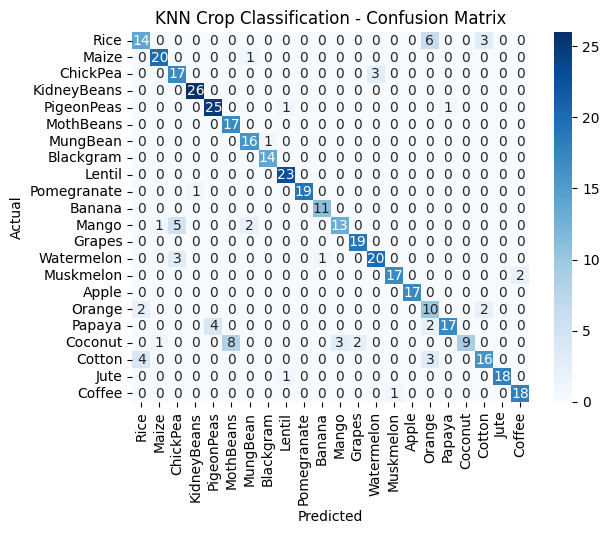

In [18]:
# Visualize confusion matrix
labels = le.classes_

k = confusion_matrix(Y_test, Y_prediction)
sns.heatmap(
    k,
    annot=True,
    fmt="d",
    cmap="Blues",

    xticklabels=['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas',
       'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate',
       'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple',
       'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee'],

    yticklabels=['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas',
       'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate',
       'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple',
       'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Crop Classification - Confusion Matrix")
plt.show()